<a href="https://colab.research.google.com/github/xtianu/CV_Tirana_2026/blob/main/M3_Image%20Classification/Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MODULE 3: IMAGE CLASSIFICATION

Christian Mata, PhD


# **EXERCISE 4**

Connecting to Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#1. Generate synthetic image with random blobs

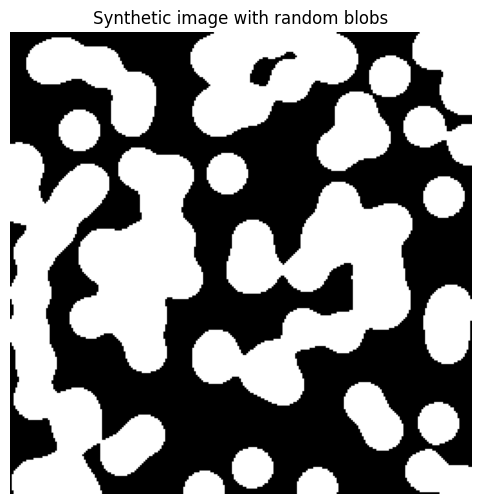

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import binary_blobs

np.random.seed(13)

blobs = binary_blobs(length=256, blob_size_fraction=0.1, volume_fraction=0.5)

fig = plt.figure(figsize=(6, 6))
plt.imshow(blobs, cmap=plt.cm.gray)
plt.axis('off')
plt.title('Synthetic image with random blobs')
plt.show()

# 2. Object segmentation and labeling

- Segmentation of blobs using Otsu's optimal threshold
- Labeling connected regions
- Visualization



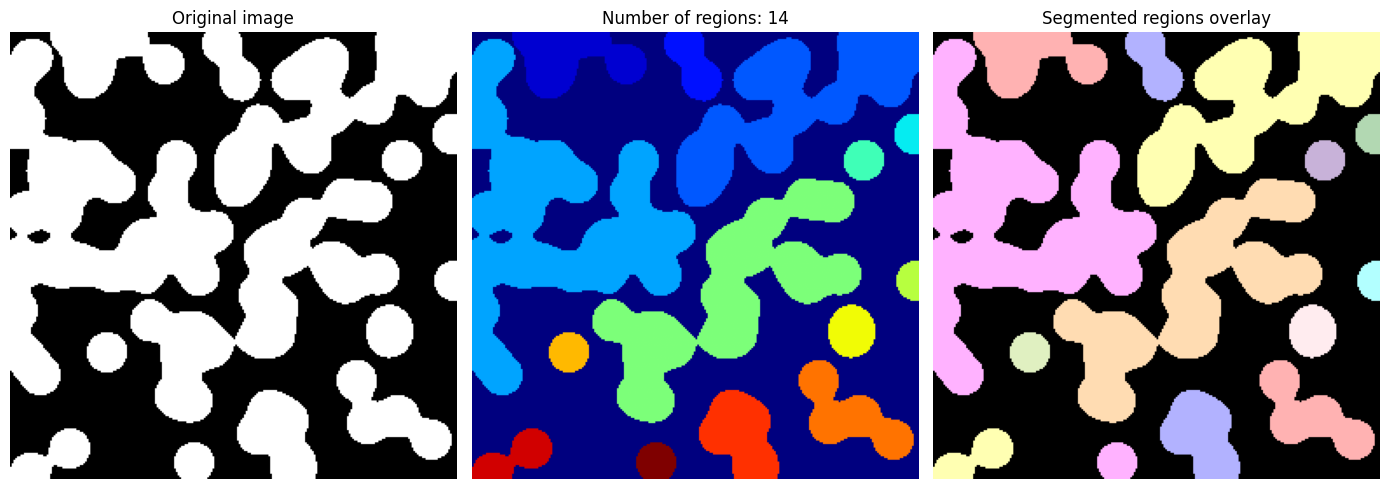

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import binary_blobs
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.color import label2rgb

np.random.seed(13)

blobs = binary_blobs(length=256, blob_size_fraction=0.1, volume_fraction=0.5)

# Otsu threshold
thresh = threshold_otsu(blobs)
bw = blobs > thresh

# Label connected regions
label_image, nregions = label(bw, return_num=True)
image_label_overlay = label2rgb(label_image, image=blobs)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 9))
ax = axes.ravel()

ax[0].imshow(blobs, cmap=plt.cm.gray)
ax[0].set_title('Original image')

ax[1].imshow(label_image, cmap=plt.cm.jet)
ax[1].set_title('Number of regions: {}'.format(nregions))

ax[2].imshow(image_label_overlay, cmap=plt.cm.jet)
ax[2].set_title('Segmented regions overlay')

ax[0].set_axis_off()
ax[1].set_axis_off()
ax[2].set_axis_off()

plt.tight_layout()
plt.show()

# 3. Get regional properties in a pandas dataframe

Function documentation with a list of available attributes can be found at https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops_table


In [7]:
import pandas as pd
import numpy as np
from skimage.data import binary_blobs
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops_table

np.random.seed(13)

blobs = binary_blobs(length=256, blob_size_fraction=0.1, volume_fraction=0.5)

thresh = threshold_otsu(blobs)
bw = blobs > thresh

label_image, nregions = label(bw, return_num=True)

props_table = regionprops_table(label_image, properties=['label', 'area', 'eccentricity', 'extent', 'axis_major_length'])

df = pd.DataFrame(props_table)
df

/usr/local/lib/python3.12/dist-packages/skimage/exposure/exposure.py:306: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, bin_edges = np.histogram(image, bins=bins, range=hist_range)


,label,area,eccentricity,extent,axis_major_length
0,1,7848.0,0.584943,0.448970,148.302879
1,2,1265.0,0.799619,0.598109,54.725180
2,3,6374.0,0.903045,0.344913,173.252597
3,4,397.0,0.225422,0.750473,22.782578
4,5,396.0,0.244589,0.748582,22.805452
5,6,8750.0,0.774780,0.453721,165.498474
6,7,5449.0,0.869371,0.375431,150.102166
7,8,707.0,0.918414,0.803409,49.265295
8,9,716.0,0.870455,0.586405,44.200281
9,10,866.0,0.742068,0.801852,40.877371


Represent area of the blobs as a function of the major axis length

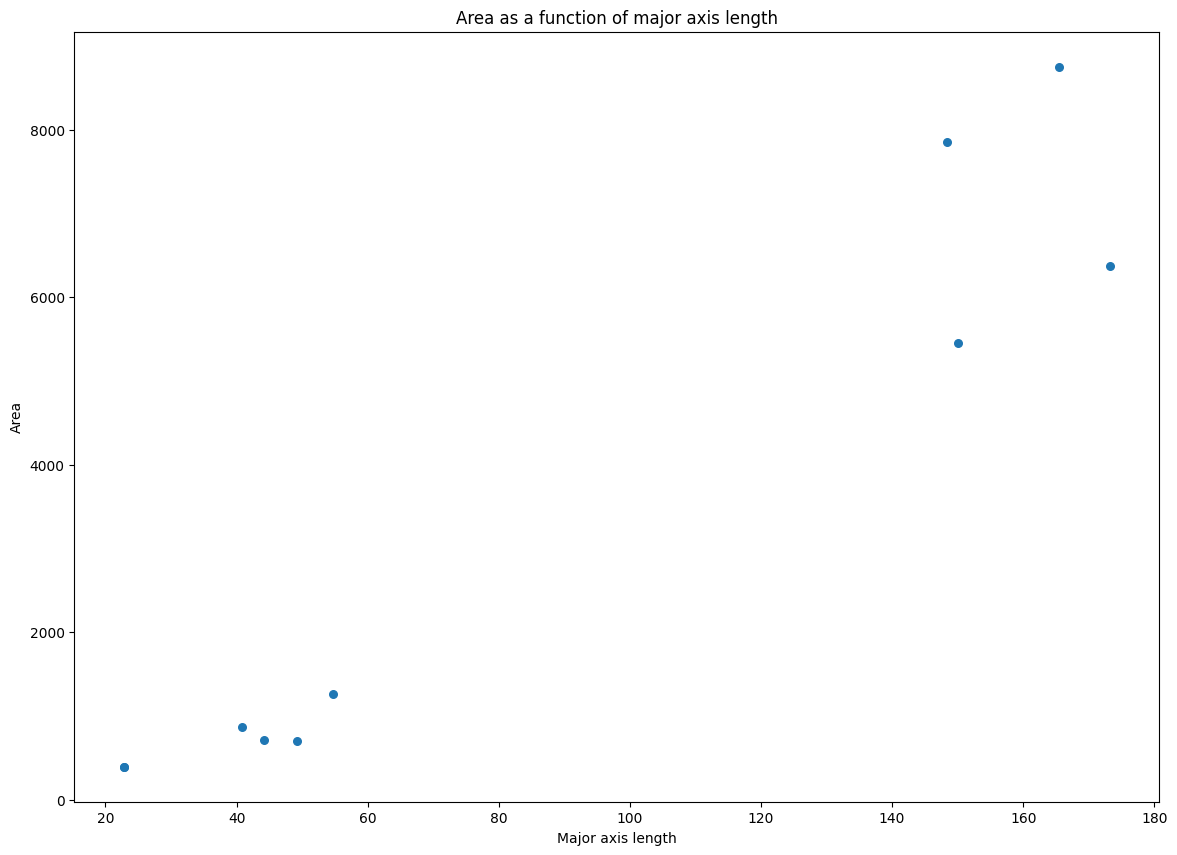

In [8]:
fig = plt.figure(figsize=(14, 10))
plt.scatter(df['axis_major_length'], df['area'], s=30, marker='o')
plt.xlabel('Major axis length')
plt.ylabel('Area')
plt.title('Area as a function of major axis length')
plt.show()

Clear correlation between blob's length and area can be observed

#4. Analyze blobs


Since you have the feature data in a pandas dataframe, you can exploit all the functions of te libraries. For instance:

How many blobs have an area above the average?

In [14]:
average_area = df['area'].mean()
large_blobs = df[df['area'] > average_area]
small_blobs = df[df['area'] < average_area]

large_blobs

,label,area,eccentricity,extent,axis_major_length
0,1,7848.0,0.584943,0.448970,148.302879
2,3,6374.0,0.903045,0.344913,173.252597
5,6,8750.0,0.774780,0.453721,165.498474
6,7,5449.0,0.869371,0.375431,150.102166


In [11]:
print('There are {} blobs with an area larger or equal the mean area {}'.format(len(large_blobs), average_area))

There are 4 blobs with an area larger or equal the mean area 3276.8


Represent the blobs that have an area smaller than the average blob's area

In [15]:
print('There are {} blobs with an area smaller than the mean area {}'.format(len(small_blobs), average_area))

There are 6 blobs with an area smaller than the mean area 3276.8


find the labels of small and large blobs

In [16]:
ind_small = np.where(df['area'] < average_area)
ind_sregions = np.array(ind_small) + 1

ind_large = np.where(df['area'] >= average_area)
ind_lregions = np.array(ind_large) + 1

print('Labels of small blobs: {}'.format(ind_sregions))
print('Labels of large blobs: {}'.format(ind_lregions))

Labels of small blobs: [[ 2  4  5  8  9 10]]
Labels of large blobs: [[1 3 6 7]]


Create a binary mask with the large and small blobs

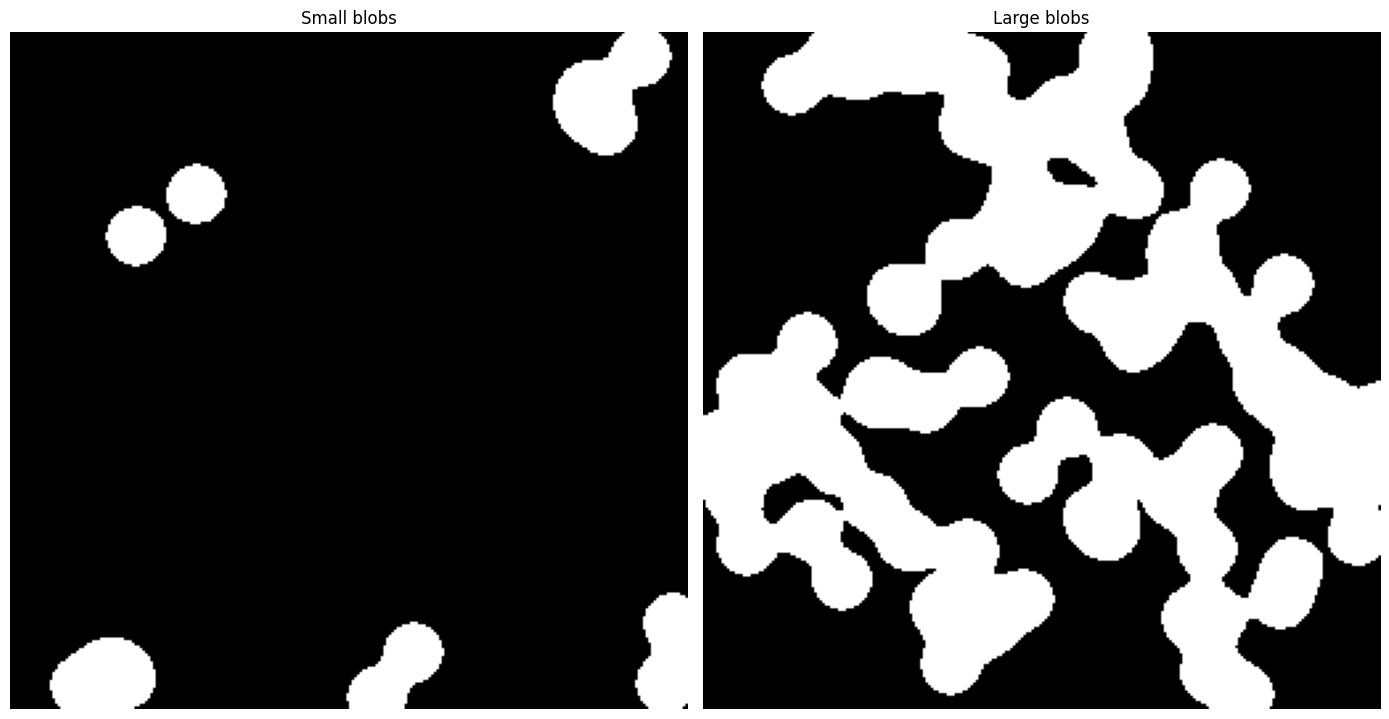

In [17]:
# Binary mask of small blobs
mask_small = np.zeros_like(label_image)
for i in np.squeeze(ind_small):
    iregion = i + 1
    mask_small[label_image == iregion] = 1

# Binary mask of large blobs
mask_large = np.zeros_like(label_image)
for i in np.squeeze(ind_large):
    iregion = i + 1
    mask_large[label_image == iregion] = 1

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
ax = axes.ravel()

ax[0].imshow(mask_small, cmap=plt.cm.gray)
ax[0].set_title('Small blobs')
ax[0].set_axis_off()

ax[1].imshow(mask_large, cmap=plt.cm.gray)
ax[1].set_title('Large blobs')
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

Represent the large and small blobs

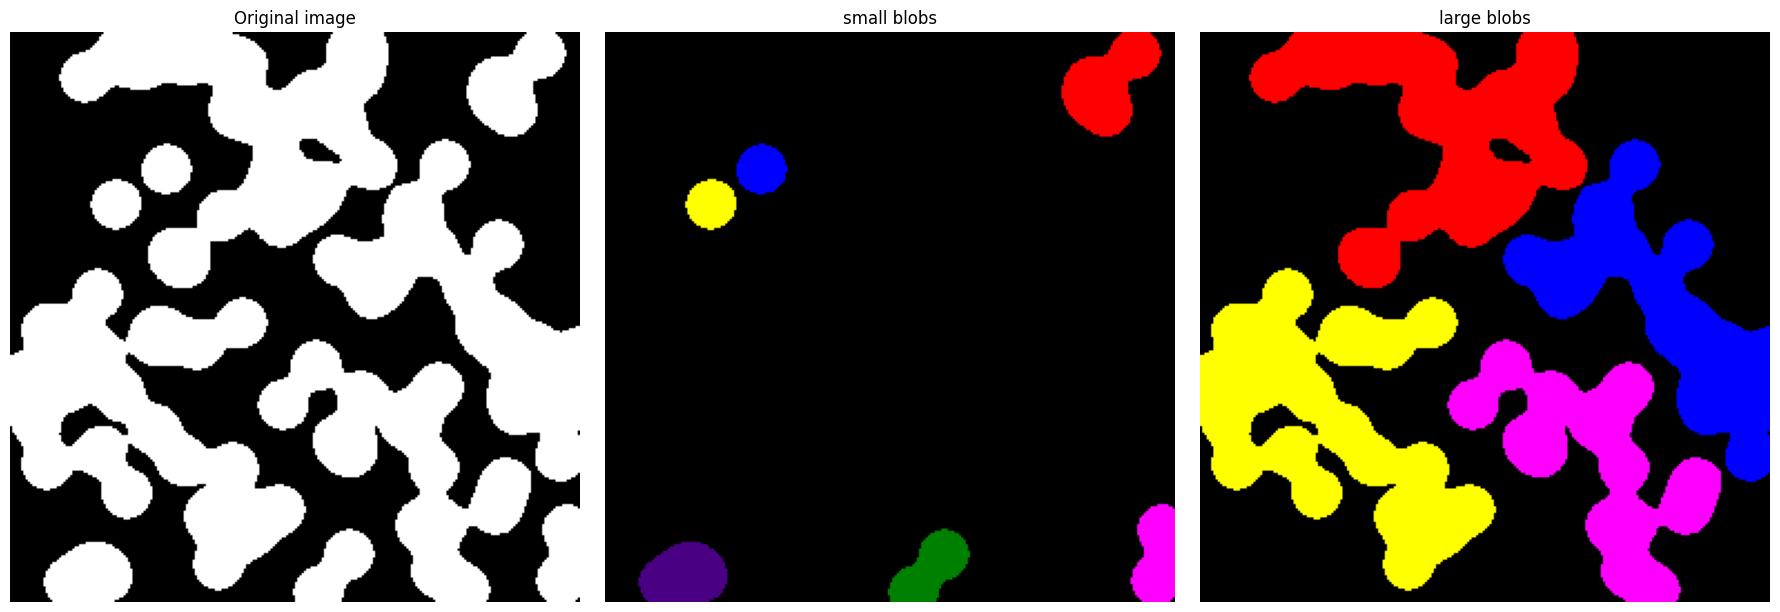

In [21]:
from skimage.color import label2rgb

label_small = np.copy(label_image)
for i in np.squeeze(ind_large):
    iregion = i + 1
    label_small[label_small == iregion] = 0

label_large = np.copy(label_image)
for i in np.squeeze(ind_small):
    iregion = i + 1
    label_large[label_large == iregion] = 0

overlay_small = label2rgb(label_small)
overlay_large = label2rgb(label_large)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax = axes.ravel()

ax[0].imshow(bw, cmap=plt.cm.gray)
ax[0].set_title('Original image')
ax[0].set_axis_off()

ax[1].imshow(overlay_small)
ax[1].set_title('small blobs')
ax[1].set_axis_off()

ax[2].imshow(overlay_large)
ax[2].set_title('large blobs')
ax[2].set_axis_off()

plt.tight_layout()
plt.show()

#5. Obtain texture-based regional properties

For the original image

In [22]:
from skimage.feature.texture import graycomatrix

g = graycomatrix(bw.astype(np.uint8), [1], [0], levels=4, normed=False, symmetric=False)

print(bw.astype(np.uint8))
print('Number of times that a grayscale level zero has a neighbour with value zero at a distance of 1 pixel to the right (angle equal zero): {}'.format(g[0,0,0,0]))
print('Number of times that a grayscale level zero has a neighbour with value 1 at a distance of 1 pixel to the right (angle equal zero): {}'.format(g[0,1,0,0]))
print('Number of times that a grayscale level 2 has a neighbour with value 2 at a distance of 1 pixel to the right (angle equal zero): {}'.format(g[2,2,0,0]))
print('Number of times that a grayscale level 2 has a neighbour with value 0 at a distance of 1 pixel to the right (angle equal zero): {}'.format(g[2,0,0,0]))

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 1 0 0]]
Number of times that a grayscale level zero has a neighbour with value zero at a distance of 1 pixel to the right (angle equal zero): 31627
Number of times that a grayscale level zero has a neighbour with value 1 at a distance of 1 pixel to the right (angle equal zero): 989
Number of times that a grayscale level 2 has a neighbour with value 2 at a distance of 1 pixel to the right (angle equal zero): 0
Number of times that a grayscale level 2 has a neighbour with value 0 at a distance of 1 pixel to the right (angle equal zero): 0


In [24]:
from skimage.feature.texture import graycomatrix, graycoprops
from skimage.measure import regionprops
import pandas as pd
import numpy as np

props = regionprops(label_image, intensity_image=bw.astype(np.uint8))
nregions = len(props)

iregion = 0
props_texture = np.zeros((nregions, 5))

for p in props:
    minr, minc, maxr, maxc = p.bbox
    I = bw.astype(np.uint8)[minc:maxc, minr:maxr]
    g = graycomatrix(I, [1], [0], levels=None, normed=True, symmetric=True)
    props_texture[iregion, 0] = graycoprops(g, 'contrast')
    props_texture[iregion, 1] = graycoprops(g, 'dissimilarity')
    props_texture[iregion, 2] = graycoprops(g, 'homogeneity')
    props_texture[iregion, 3] = graycoprops(g, 'energy')
    props_texture[iregion, 4] = graycoprops(g, 'correlation')
    iregion += 1

df_texture = pd.DataFrame(props_texture, columns=['Contrast', 'Dissimilarity', 'Homogeneity', 'Energy', 'Correlation'])
df_texture

/tmp/ipykernel_13287/734241786.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  props_texture[iregion, 0] = graycoprops(g, 'contrast')
/tmp/ipykernel_13287/734241786.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  props_texture[iregion, 1] = graycoprops(g, 'dissimilarity')
/tmp/ipykernel_13287/734241786.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  props_texture[iregion, 2] = graycoprops(g, 'homogeneity')
/tmp/ipykernel_13287/734241786.py:19: Deprec

,Contrast,Dissimilarity,Homogeneity,Energy,Correlation
0,0.025162,0.025162,0.987419,0.696860,0.948635
1,0.017874,0.017874,0.991063,0.758616,0.956077
2,0.034749,0.034749,0.982625,0.683634,0.930376
3,0.059289,0.059289,0.970356,0.668002,0.880947
4,0.019763,0.019763,0.990119,0.811625,0.938604
5,0.028665,0.028665,0.985667,0.687165,0.942665
6,0.034258,0.034258,0.982871,0.690399,0.930125
7,0.040698,0.040698,0.979651,0.684201,0.917420
8,0.009291,0.009291,0.995355,0.904130,0.946404
9,0.029808,0.029808,0.985096,0.783246,0.916647
